# MLA+ROPE

## Lets first conquer ROPE technique

### Rotary Positional Encoding

#### First lets compute Query or Key matrix for better understanding


In [48]:
import torch

In [49]:
input_seq = "<s> The cat sat </s>" #simple example to understand everything better
#<S>=start of the sentence
#</s>=end of the sentence
tokens = input_seq.split()
print(tokens)

['<s>', 'The', 'cat', 'sat', '</s>']


In [50]:
#setting hyperparameters
vocab_size = 100 #just an arbitary number
d_model = 16
n_heads = 2 #number of heads
max_seq_len = 10 
head_dim = d_model//n_heads #8

We assign integer IDs to each token (for illustration):

s → 0

The → 15

cat → 42

sat → 77

/s → 1

In [51]:
ids = torch.tensor([[0, 15, 42, 77, 1]])
print(ids.shape)

torch.Size([1, 5])


##### embeddings

In [52]:
embedding_layer = torch.nn.Embedding(vocab_size,d_model)
embeddings = embedding_layer(ids)
print(embeddings.shape)

torch.Size([1, 5, 16])


##### q and k

In [53]:
w_q = torch.nn.Linear(d_model,d_model)
w_k = torch.nn.Linear(d_model,d_model)
w_v = torch.nn.Linear(d_model,d_model)
Q,K,V = w_q(embeddings),w_k(embeddings),w_v(embeddings)
print(Q.shape)


torch.Size([1, 5, 16])


In [54]:
batch,seq_len,d = Q.shape # (1,5,16)
Q = Q.view(batch,seq_len,n_heads,head_dim)#(1,5,2,8)
K = K.view(batch,seq_len,n_heads,head_dim)#same
V = V.view(batch,seq_len,n_heads,head_dim)#:)

##### Rope - frequency complex matrix computation

###### computing thetha 

In [55]:
x = torch.arange(0,head_dim,2).float() #[0,2,..,8-2] head_dim = 8
x

tensor([0., 2., 4., 6.])

In [56]:
i = x/head_dim
i

tensor([0.0000, 0.2500, 0.5000, 0.7500])

In [57]:
thetha = 1/(10000**(i))
thetha

tensor([1.0000, 0.1000, 0.0100, 0.0010])

###### computing frequency

In [58]:
positions = torch.arange(max_seq_len)
positions

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [59]:
#the outer product
print(positions.shape)
m = positions.reshape(-1,1) 
print(m.shape)
print(thetha.shape)
angles = m*thetha
print(angles)
print(angles.shape)


torch.Size([10])
torch.Size([10, 1])
torch.Size([4])
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.0000e+00, 1.0000e-01, 1.0000e-02, 1.0000e-03],
        [2.0000e+00, 2.0000e-01, 2.0000e-02, 2.0000e-03],
        [3.0000e+00, 3.0000e-01, 3.0000e-02, 3.0000e-03],
        [4.0000e+00, 4.0000e-01, 4.0000e-02, 4.0000e-03],
        [5.0000e+00, 5.0000e-01, 5.0000e-02, 5.0000e-03],
        [6.0000e+00, 6.0000e-01, 6.0000e-02, 6.0000e-03],
        [7.0000e+00, 7.0000e-01, 7.0000e-02, 7.0000e-03],
        [8.0000e+00, 8.0000e-01, 8.0000e-02, 8.0000e-03],
        [9.0000e+00, 9.0000e-01, 9.0000e-02, 9.0000e-03]])
torch.Size([10, 4])


In [60]:
#implementing euler formula
frequency_complex_matrix = torch.complex(torch.cos(angles),torch.sin(angles)) #torch.complex(real,imaginary)
frequency_complex_matrix

tensor([[ 1.0000+0.0000j,  1.0000+0.0000j,  1.0000+0.0000j,  1.0000+0.0000j],
        [ 0.5403+0.8415j,  0.9950+0.0998j,  0.9999+0.0100j,  1.0000+0.0010j],
        [-0.4161+0.9093j,  0.9801+0.1987j,  0.9998+0.0200j,  1.0000+0.0020j],
        [-0.9900+0.1411j,  0.9553+0.2955j,  0.9996+0.0300j,  1.0000+0.0030j],
        [-0.6536-0.7568j,  0.9211+0.3894j,  0.9992+0.0400j,  1.0000+0.0040j],
        [ 0.2837-0.9589j,  0.8776+0.4794j,  0.9988+0.0500j,  1.0000+0.0050j],
        [ 0.9602-0.2794j,  0.8253+0.5646j,  0.9982+0.0600j,  1.0000+0.0060j],
        [ 0.7539+0.6570j,  0.7648+0.6442j,  0.9976+0.0699j,  1.0000+0.0070j],
        [-0.1455+0.9894j,  0.6967+0.7174j,  0.9968+0.0799j,  1.0000+0.0080j],
        [-0.9111+0.4121j,  0.6216+0.7833j,  0.9960+0.0899j,  1.0000+0.0090j]])

In [61]:
# magnitude check
import math
val = frequency_complex_matrix[1][0]
print(val)
magnitude = math.sqrt(val.real**2+val.imag**2)
print(magnitude)

tensor(0.5403+0.8415j)
1.0


##### applying to Q and K

In [62]:
print(Q.shape)
print(K.shape)
print(frequency_complex_matrix.shape)

torch.Size([1, 5, 2, 8])
torch.Size([1, 5, 2, 8])
torch.Size([10, 4])


we need to reshape freq_complex_matrix for matmul

In [63]:
q_ = torch.view_as_complex(Q.float().reshape(*Q.shape[:-1],-1,2))
k_ = torch.view_as_complex(K.float().reshape(*K.shape[:-1],-1,2))
print(q_.shape)
print(k_.shape)

torch.Size([1, 5, 2, 4])
torch.Size([1, 5, 2, 4])


In [64]:
frequency_complex_matrix = frequency_complex_matrix[:Q.shape[1]].unsqueeze(0).unsqueeze(2)
print(frequency_complex_matrix.shape)

torch.Size([1, 5, 1, 4])


In [65]:
q = torch.view_as_real(q_*frequency_complex_matrix).flatten(3)#this combines from third dimension in Shape
q.shape
k = torch.view_as_real(k_*frequency_complex_matrix).flatten(3)

In [66]:
print(q.type_as(Q),k.type_as(K))

tensor([[[[ 0.9594, -0.1479, -0.3049,  0.7300,  0.7456,  0.2444,  0.4912,
            0.2243],
          [ 0.7204,  0.2322,  1.3326,  0.4453, -1.2415, -0.8950,  0.2520,
            0.1513]],

         [[ 0.2397,  1.1576,  0.0487,  0.3625, -0.0543, -1.0022, -0.2127,
           -0.4803],
          [-0.0621, -0.6121, -0.4367,  1.0137,  0.2858, -0.3267,  0.7004,
            1.0295]],

         [[ 0.5871, -0.0386, -0.2221,  0.2594,  0.1807, -0.4275,  0.4095,
            0.8276],
          [-0.1730,  0.1581, -1.0917,  0.1027,  0.3738, -0.2228,  0.0353,
           -0.2940]],

         [[-0.3145,  0.7597, -0.0779, -0.0567,  0.0362,  0.8128, -0.1438,
            0.1689],
          [ 0.3287, -0.4847,  0.4011,  0.4509, -0.6597, -0.0440,  0.1498,
            0.9173]],

         [[-0.1395, -0.0336,  0.1413,  0.2263, -0.0202,  0.8059, -0.3684,
            0.2828],
          [ 1.1732, -0.4340, -1.0381,  0.3767,  0.5956, -0.0402, -1.0224,
            0.1608]]]], grad_fn=<ViewBackward0>) tensor([[[[-0.

In [120]:
def precompute_freqs_cis(d_k,max_seq_len,base = 10000):
    thetha = 1/(base**(torch.arange(0,d_k,2).float()/d_k))
    positions = torch.arange(max_seq_len)
    freq = torch.outer(positions,thetha)
    freq = torch.polar(torch.ones_like(freq),freq)
    return freq

def apply_rope(x,max_seq_len):
    b,s,n,d = x.shape
    x_ = torch.view_as_complex(x.float().reshape(b,s,n,-1,2))
    freq_cis = precompute_freqs_cis(d,max_seq_len)
    freq_cis = freq_cis[:s].unsqueeze(0).unsqueeze(2)
    out = torch.view_as_real(x_*freq_cis).flatten(3)
    return out.type_as(x)

## Now the core MLA

### MLA Part1: Training

In [ ]:
#dimensions
d_latent = 4 #KV Cache dim
d_latent_q = 4 # Q matrix compression dim
d_rope = 2 # per head RoPE dim

In [ ]:
W_uk = torch.nn.Linear(d_latent,n_heads*head_dim)#4,2*8=4,16
W_uv = torch.nn.Linear(d_latent,n_heads*head_dim)#4,8
W_uq = torch.nn.Linear(d_latent,d_model)#4,16
'''
these are upward projection matrices which help in reconstruction
of keys and values from lower dimension latent space cache matrix
''' 
W_dkv = torch.nn.Linear(d_model,d_latent) #lower dimension cache - 16,4
W_dq = torch.nn.Linear(d_model,d_latent_q) #downward projection for query matrix(16,4
W_o = torch.nn.Linear(d_model,d_model)

In [102]:
print(batch,seq_len,n_heads,head_dim,d_model)

1 5 2 8 16


In [96]:
print(embeddings.shape)

torch.Size([1, 5, 16])


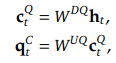

same goes with K

In [130]:
cq = W_dq(embeddings)
q_nope = W_uq(cq)

ckv = W_dkv(embeddings)
k_nope = W_uk(ckv)

print(f'shape of q_nope: {q_nope.shape}')
print(f'shpae of k_nope: {k_nope.shape}')
q_nope = q_nope.view(batch,seq_len,n_heads,head_dim)
print(q_nope.shape)
k_nope = k_nope.view(batch,seq_len,n_heads,head_dim)
print(k_nope.shape)

shape of q_nope: torch.Size([1, 5, 16])
shpae of k_nope: torch.Size([1, 5, 16])
torch.Size([1, 5, 2, 8])
torch.Size([1, 5, 2, 8])


#### Decoupling RoPE

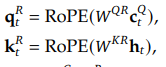

In [106]:
print(cq.shape)

torch.Size([1, 5, 4])


In [107]:
#right, I forgot:
#the q is coming from latent vector not from the input
W_qr = torch.nn.Linear(d_latent_q,n_heads*d_rope)
W_kr = torch.nn.Linear(d_model,d_rope)#16,2 because this is shared among all the heads **

q_rope = W_qr(cq)
print(f'before applying rope: ')
print(q_rope.shape)
k_rope = W_kr(embeddings)
print(k_rope.shape)
#reshape this

before applying rope: 
torch.Size([1, 5, 4])
torch.Size([1, 5, 2])


In [121]:
qr = q_rope.view(batch,seq_len,n_heads,d_rope)
print(qr.shape)
kr = k_rope.unsqueeze(2) #we need to apply at n_heads as it's one = as it's shared across
#all heads
print(kr.shape)
qr = apply_rope(qr,max_seq_len)
kr = apply_rope(kr,max_seq_len)
print(qr.shape,kr.shape)

torch.Size([1, 5, 2, 2])
torch.Size([1, 5, 1, 2])
torch.Size([1, 5, 2, 2]) torch.Size([1, 5, 1, 2])


#### concatenation

In [ ]:
print(k_nope.shape,kr.shape)

torch.Size([1, 5, 2, 8]) torch.Size([1, 5, 1, 2])


In [129]:
#in order match both of the dimensions we need to broadcast kr
K_full = torch.cat([k_nope, kr.expand(-1, -1, n_heads, -1)], dim=-1)
K_full.shape

torch.Size([1, 5, 2, 10])

In [128]:
Q_full = torch.cat([q_nope,qr],dim=-1)
print(Q_full.shape)

torch.Size([1, 5, 2, 10])


In [131]:
v = W_uv(ckv)
v = v.view(batch,seq_len,n_heads,head_dim)

### MLA Part2: Inference

In [137]:
#the only difference between training and inference part are absorbption of query and Wo
W_uq_abs = torch.nn.Linear(d_latent_q,d_latent)
W_o_abs = torch.nn.Linear(d_latent,d_model)

W_uq_abs.weight.data = W_uk.weight.T@W_uq.weight
W_o_abs.weight.data = W_o.weight @ W_uv.weight #this is applied at last

In [138]:
q_inf = W_uq_abs(cq)
 